# Jacobian normalization for simplest class  of stiff ODEs: $\frac{dy}{dx} = -Cy$

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.autograd as autograd
from torch.optim.lr_scheduler import ExponentialLR
import numpy as np
import matplotlib.pyplot as plt

from pinn import PINN

In [2]:
def plotting(C, preds, x_coloc):

    x_coloc = x_coloc.detach().numpy()
    
    plt.figure(figsize=(10,8))
    plt.plot(x_coloc, preds, 'r', label='PINN')
    plt.plot(x_coloc, np.exp(-C * x_coloc), color='green', linestyle=':', label='Exact solution')
    plt.xlabel(r'$x$') 
    plt.ylabel(r'$y$') 
    plt.xscale('log')
    plt.legend()
    plt.show()

## PINN parameters

In [3]:
# Parameters of this problem:
normalize_jacobian = True
C_test = np.logspace(0, 4, 20, endpoint=True)
early_stopping_loss = 1e-8

n_epochs = 500_000
num_coloc = 1000
lr = 8.0e-5
x_co = np.exp(np.linspace(-15.0, 0.0, num_coloc))
x_co = torch.tensor(x_co, dtype=torch.float32).view(-1, 1).requires_grad_(True)

## Loss function

In [4]:
def make_loss(C, normalize_jac):
    def pinn_loss(self, x):
            
        x = x.clone().detach().requires_grad_(True)

        # Forward pass
        y = self.forward(x)

        # dy/dx via autograd
        dy_dx = torch.autograd.grad(
            outputs=y,
            inputs=x,
            grad_outputs=torch.ones_like(y),
            create_graph=True,
            retain_graph=True
        )[0]

        lhs = dy_dx
        rhs = - C * y

        residual = (lhs - rhs)
        ode_loss = torch.mean(residual**2 / (1.0 + normalize_jac * C**2))
        x0_loss = torch.square(y[0] - torch.exp(-C * x[0]))

        total_loss = ode_loss + x0_loss
        
        return ode_loss, x0_loss, total_loss
    return pinn_loss

## PINN training

In [5]:
def training(n_epochs, C):
    
    print("-----------------------------------------")
    print(f"Running for C = {C}")
    print("-----------------------------------------")

    loss_fn = make_loss(C, normalize_jacobian)
    model = PINN(40, 4, 1, lr, loss_fn)
    scheduler = ExponentialLR(model.optimizer, gamma=0.99)

    best_loss = 10
    
    for epoch in range(n_epochs):
        losses = model.train_step(x_co)
        if epoch % 1000 == 0:
            scheduler.step()
        if epoch % 10000 == 0:
            print(f"Epoch {epoch:3d} | Best: {best_loss:.6f} | Total: {losses['total_loss']:.6f} | ODE: {losses['ode_loss']:.6f} | IC: {losses['x0_loss']:.6f}")
    
        if losses['total_loss'] < best_loss: 
            torch.save(model.state_dict(), './dataToys/best-Toy1-norm' + str(normalize_jacobian) + '-' + str(int(np.ceil(C))) + '.pt')
            best_loss = losses['total_loss']

        if best_loss < early_stopping_loss:
            break

    
    best_model = PINN(40, 4, 1, lr, loss_fn)
    best_model.load_state_dict(torch.load('./dataToys/best-Toy1-norm' + str(normalize_jacobian) + '-' + str(int(np.ceil(C))) + '.pt'))
    
    preds = best_model.predict(x_co)
    
    plotting(C, preds, x_co)

    eig_max = best_model.compute_largest_hessian_eigenvalue(x_co)

    return eig_max

In [6]:
def experiment(j_list, n_epochs):

    hessian_eig_lst = []

    for j in j_list:

        eig_max = training(n_epochs, j)
        hessian_eig_lst.append(eig_max)

    return hessian_eig_lst

-----------------------------------------
Running for C = 1.0
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.975651 | ODE: 0.000027 | IC: 0.975623
Epoch 10000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


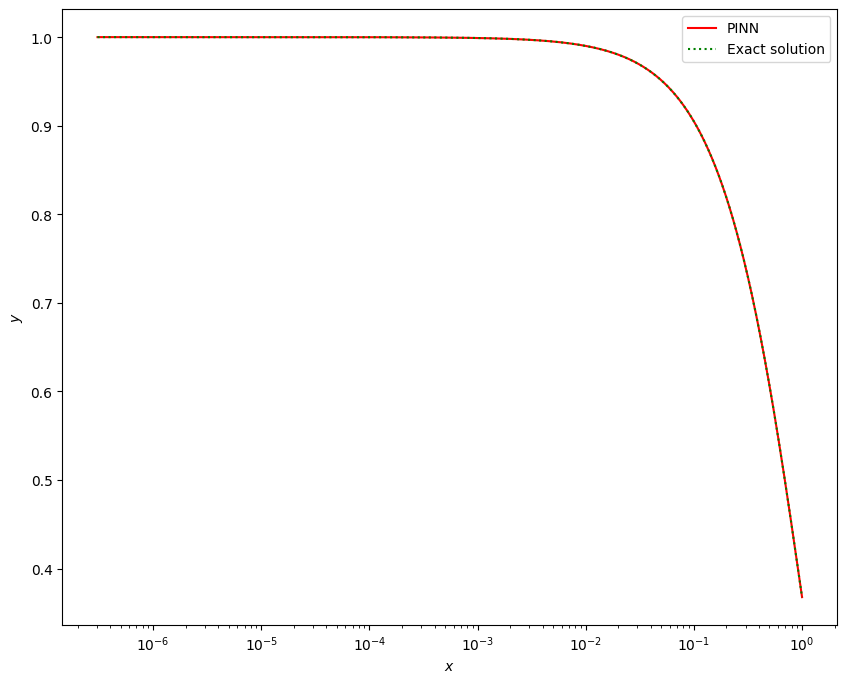

-----------------------------------------
Running for C = 1.6237767391887217
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.991378 | ODE: 0.000077 | IC: 0.991302
Epoch 10000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


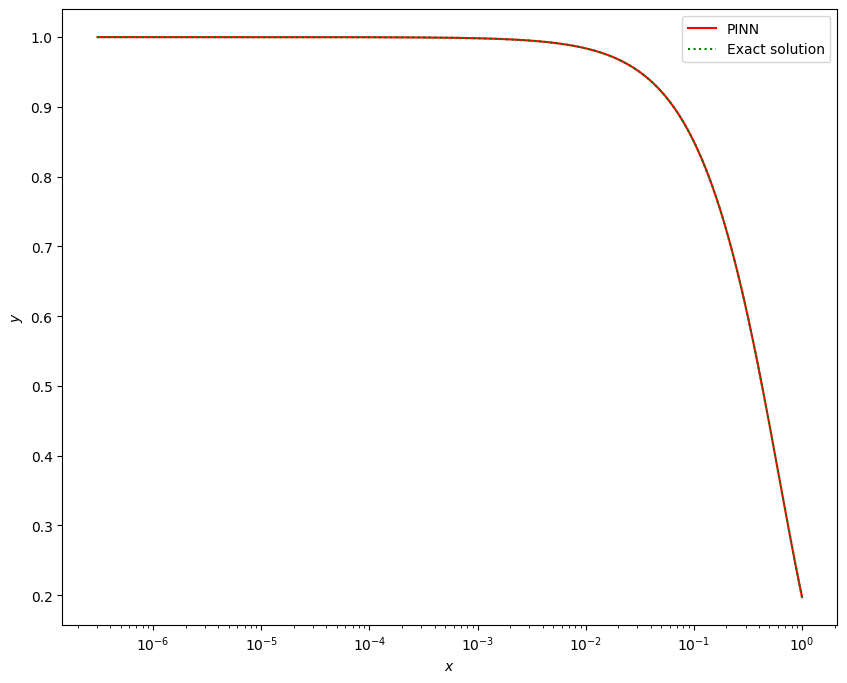

-----------------------------------------
Running for C = 2.636650898730358
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.797922 | ODE: 0.011033 | IC: 0.786890
Epoch 10000 | Best: 0.000005 | Total: 0.000005 | ODE: 0.000005 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


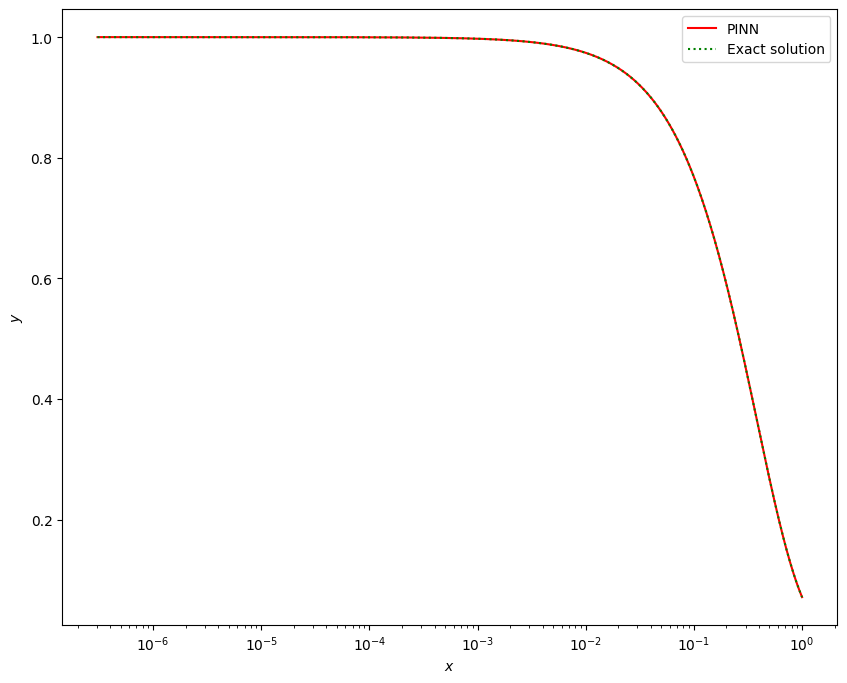

-----------------------------------------
Running for C = 4.281332398719393
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.268661 | ODE: 0.013938 | IC: 1.254722
Epoch 10000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


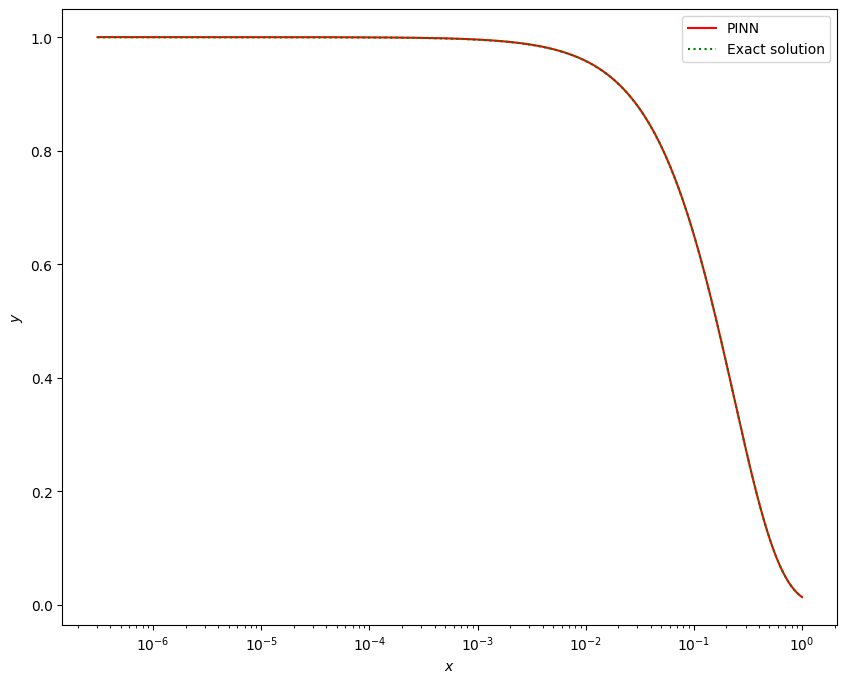

-----------------------------------------
Running for C = 6.951927961775605
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.221318 | ODE: 0.010001 | IC: 1.211317
Epoch 10000 | Best: 0.000006 | Total: 0.000006 | ODE: 0.000006 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


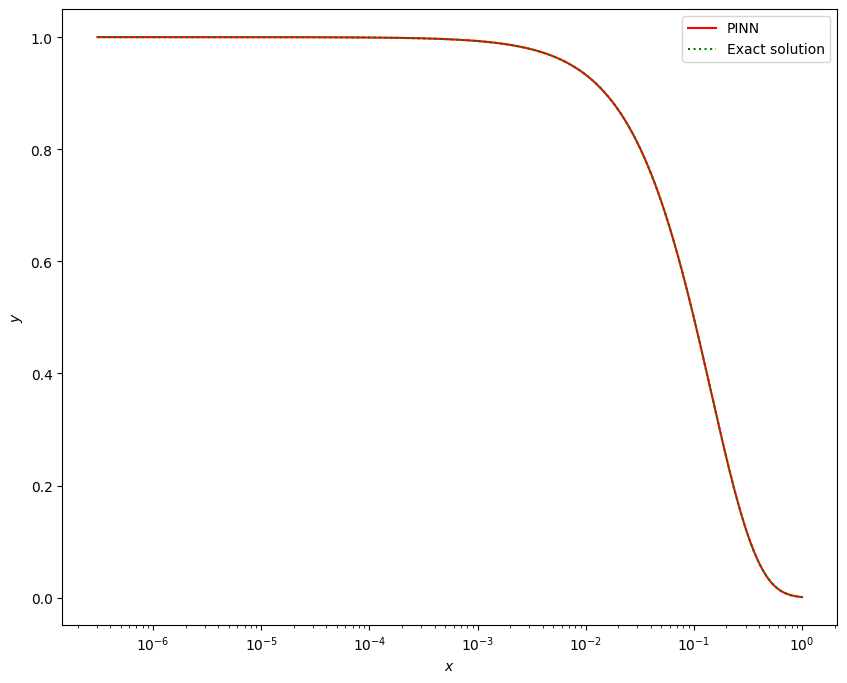

-----------------------------------------
Running for C = 11.28837891684689
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.932261 | ODE: 0.001252 | IC: 0.931010
Epoch 10000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000


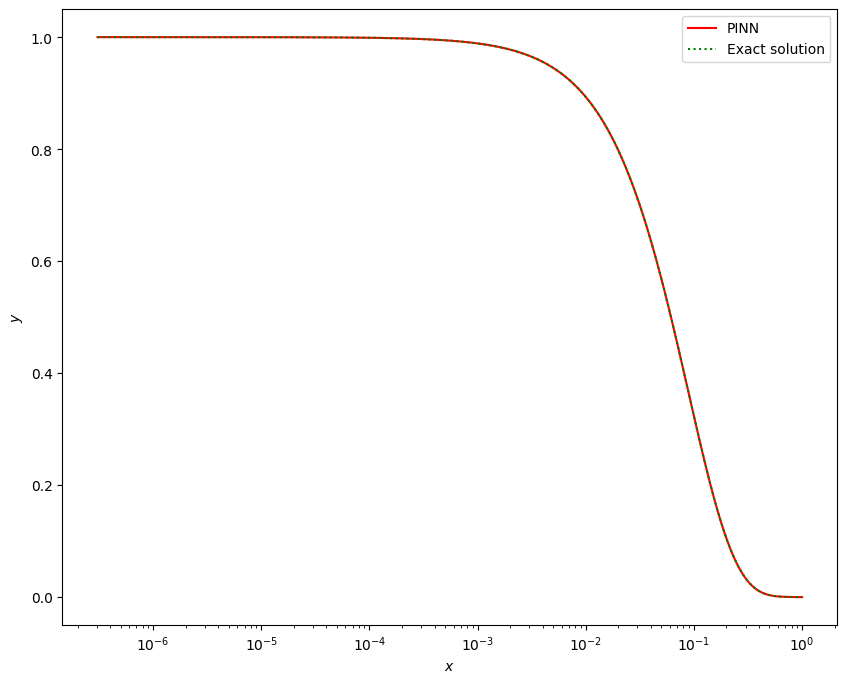

-----------------------------------------
Running for C = 18.329807108324356
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.320589 | ODE: 0.019762 | IC: 1.300827
Epoch 10000 | Best: 0.000001 | Total: 0.000002 | ODE: 0.000001 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.

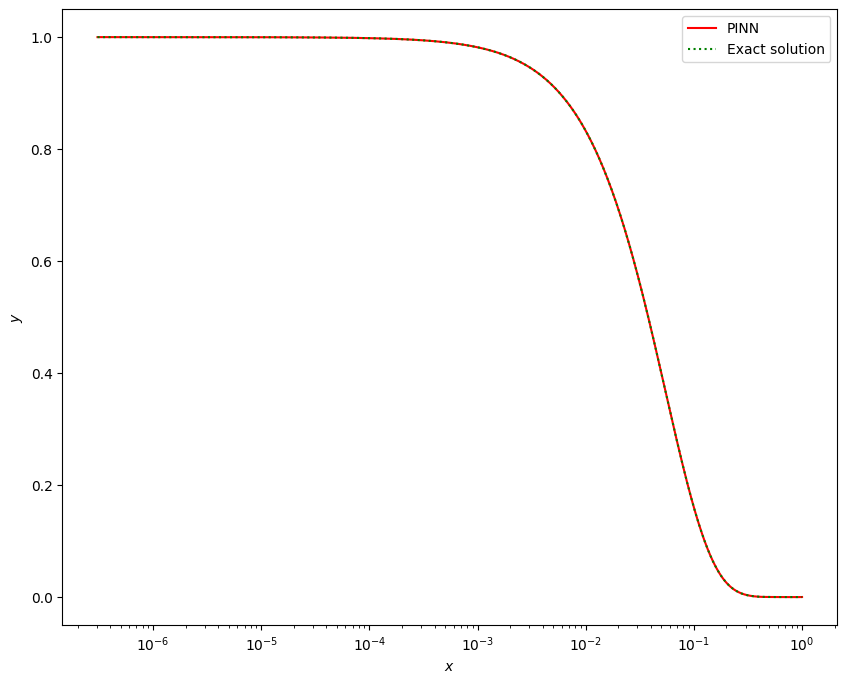

-----------------------------------------
Running for C = 29.763514416313175
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.229993 | ODE: 0.010811 | IC: 1.219183
Epoch 10000 | Best: 0.000007 | Total: 0.000007 | ODE: 0.000007 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.

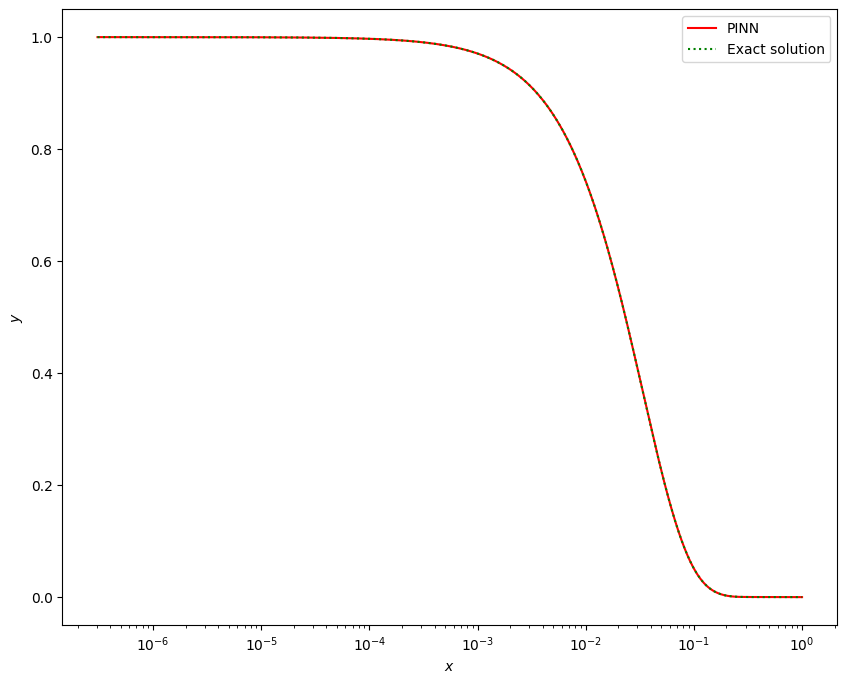

-----------------------------------------
Running for C = 48.32930238571752
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.220474 | ODE: 0.010079 | IC: 1.210395
Epoch 10000 | Best: 0.000006 | Total: 0.000006 | ODE: 0.000006 | IC: 0.000000
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 40000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

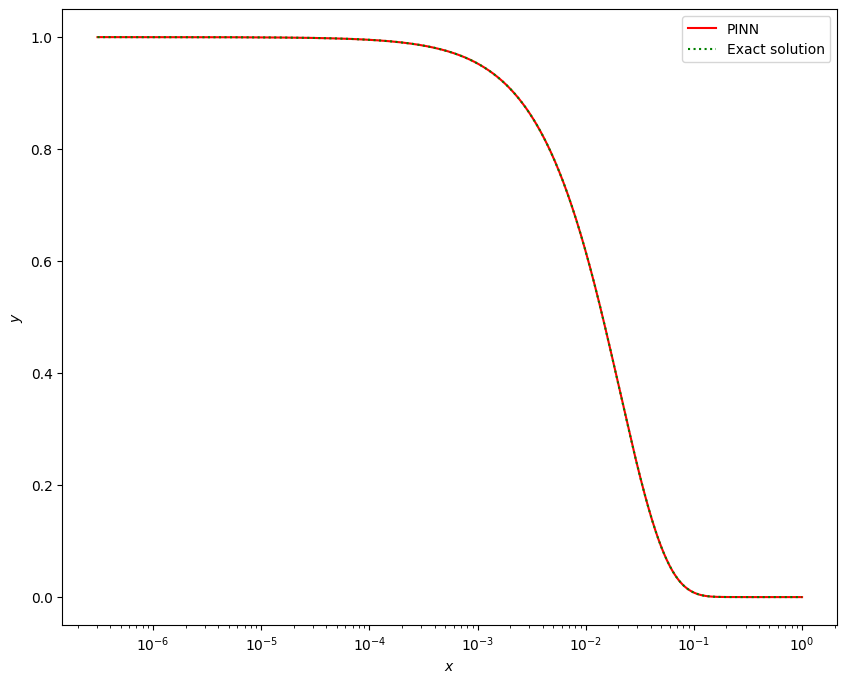

-----------------------------------------
Running for C = 78.47599703514611
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.942871 | ODE: 0.000897 | IC: 0.941974
Epoch 10000 | Best: 0.000005 | Total: 0.000008 | ODE: 0.000005 | IC: 0.000003
Epoch 20000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 30000 | Best: 0.000000 | Total: 0.000024 | ODE: 0.000000 | IC: 0.000024
Epoch 40000 | Best: 0.000000 | Total: 0.000008 | ODE: 0.000000 | IC: 0.000008
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.0

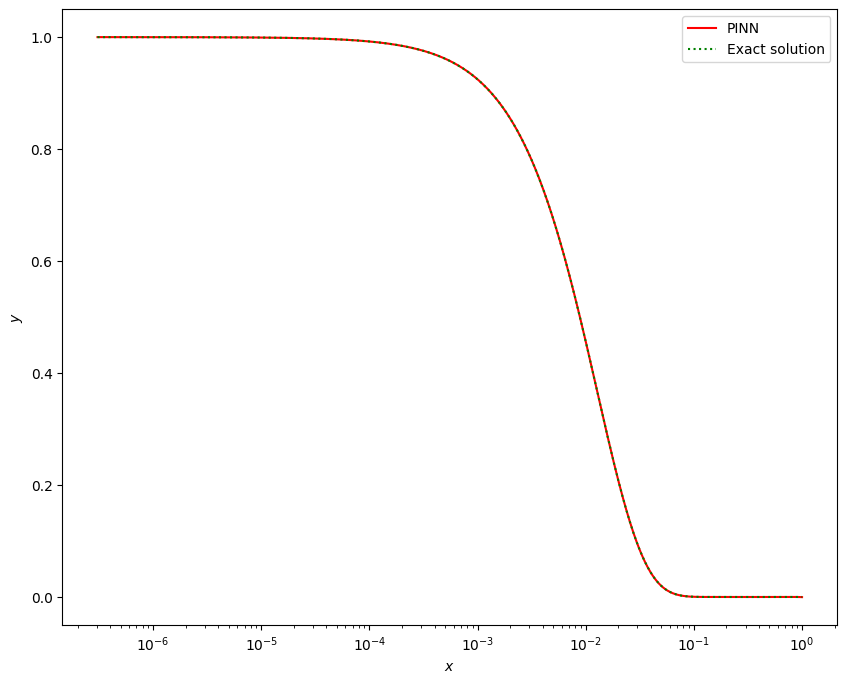

-----------------------------------------
Running for C = 127.42749857031335
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.723852 | ODE: 0.027445 | IC: 0.696407
Epoch 10000 | Best: 0.000033 | Total: 0.000033 | ODE: 0.000033 | IC: 0.000000
Epoch 20000 | Best: 0.000002 | Total: 0.000072 | ODE: 0.000003 | IC: 0.000070
Epoch 30000 | Best: 0.000001 | Total: 0.000020 | ODE: 0.000001 | IC: 0.000019
Epoch 40000 | Best: 0.000001 | Total: 0.000002 | ODE: 0.000001 | IC: 0.000001
Epoch 50000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 60000 | Best: 0.000001 | Total: 0.000008 | ODE: 0.000001 | IC: 0.000008
Epoch 70000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 80000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.

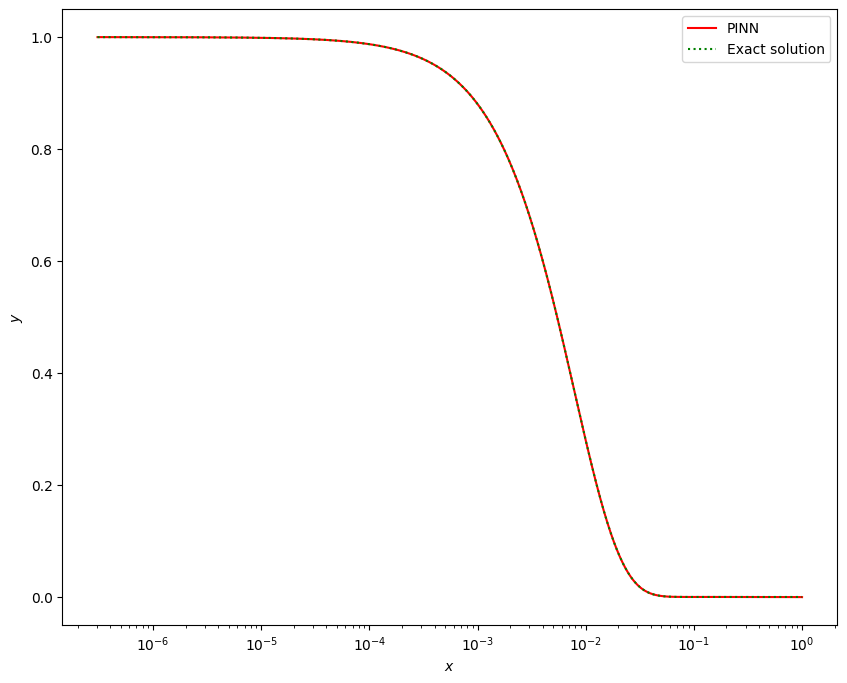

-----------------------------------------
Running for C = 206.913808111479
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.964529 | ODE: 0.000335 | IC: 0.964194
Epoch 10000 | Best: 0.000152 | Total: 0.000154 | ODE: 0.000150 | IC: 0.000004
Epoch 20000 | Best: 0.000007 | Total: 0.000007 | ODE: 0.000007 | IC: 0.000000
Epoch 30000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 40000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 70000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000001 | ODE: 0.000000 | IC: 0.000001
Epoch 90000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 110000 | Best: 0.00

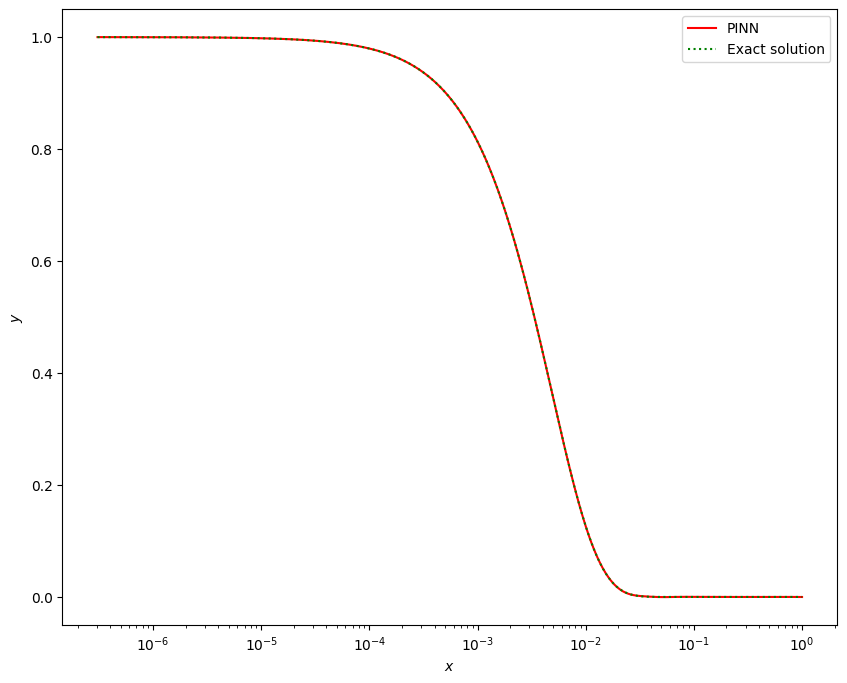

-----------------------------------------
Running for C = 335.9818286283781
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.989071 | ODE: 0.000027 | IC: 0.989044
Epoch 10000 | Best: 0.000239 | Total: 0.000246 | ODE: 0.000235 | IC: 0.000012
Epoch 20000 | Best: 0.000006 | Total: 0.000006 | ODE: 0.000006 | IC: 0.000000
Epoch 30000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 40000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000001
Epoch 50000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 60000 | Best: 0.000000 | Total: 0.000012 | ODE: 0.000000 | IC: 0.000012
Epoch 70000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 80000 | Best: 0.000000 | Total: 0.000000 | ODE: 0.000000 | IC: 0.000000
Epoch 90000 | Best: 0.000000 | Total: 0.000003 | ODE: 0.000000 | IC: 0.000003
Epoch 100000 | Best: 0.000000 | Total: 0.000008 | ODE: 0.000000 | IC: 0.000007
Epoch 110000 | Best: 0.0

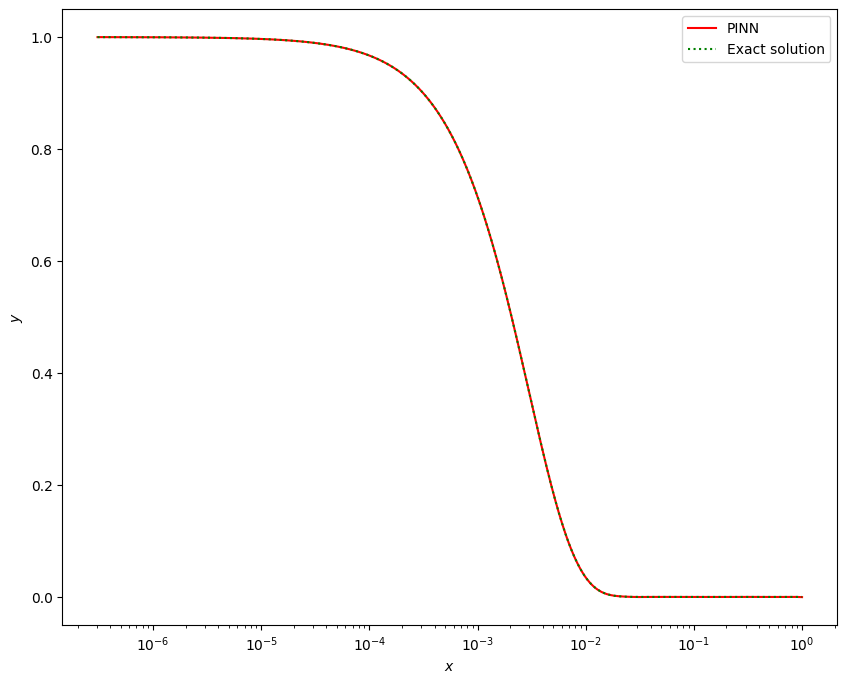

-----------------------------------------
Running for C = 545.5594781168514
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.070071 | ODE: 0.001167 | IC: 1.068904
Epoch 10000 | Best: 0.001020 | Total: 0.001020 | ODE: 0.001013 | IC: 0.000007
Epoch 20000 | Best: 0.000025 | Total: 0.000028 | ODE: 0.000025 | IC: 0.000003
Epoch 30000 | Best: 0.000004 | Total: 0.000006 | ODE: 0.000004 | IC: 0.000002
Epoch 40000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 50000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 60000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 70000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 80000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 90000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 100000 | Best: 0.000000 | Total: 0.000010 | ODE: 0.000001 | IC: 0.000009
Epoch 110000 | Best: 0.0

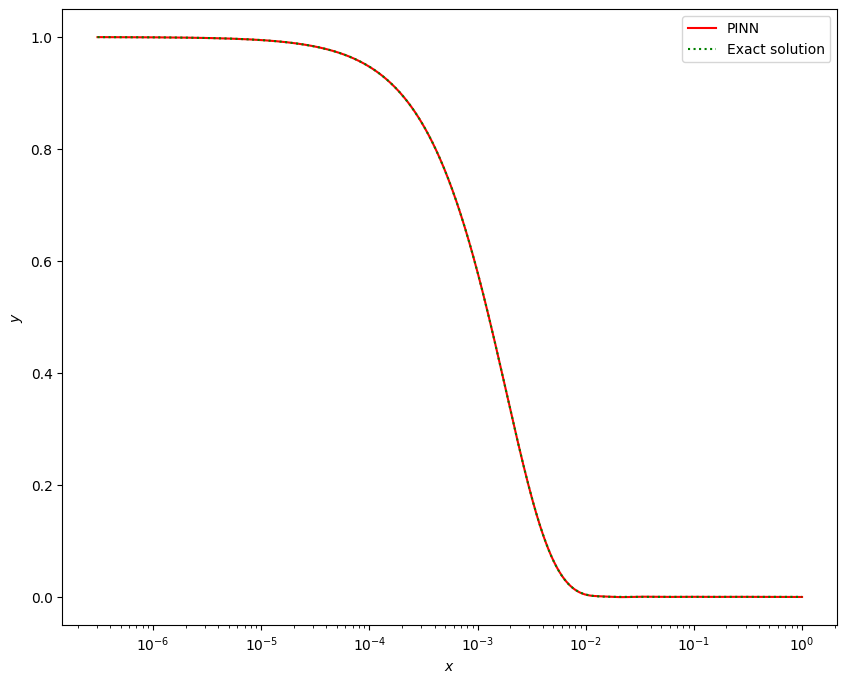

-----------------------------------------
Running for C = 885.8667904100823
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.301291 | ODE: 0.017854 | IC: 1.283436
Epoch 10000 | Best: 0.007849 | Total: 0.008754 | ODE: 0.006792 | IC: 0.001961
Epoch 20000 | Best: 0.000156 | Total: 0.000236 | ODE: 0.000164 | IC: 0.000072
Epoch 30000 | Best: 0.000012 | Total: 0.000012 | ODE: 0.000012 | IC: 0.000000
Epoch 40000 | Best: 0.000005 | Total: 0.000005 | ODE: 0.000005 | IC: 0.000001
Epoch 50000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 60000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 70000 | Best: 0.000002 | Total: 0.000019 | ODE: 0.000002 | IC: 0.000017
Epoch 80000 | Best: 0.000002 | Total: 0.000002 | ODE: 0.000002 | IC: 0.000000
Epoch 90000 | Best: 0.000001 | Total: 0.000001 | ODE: 0.000001 | IC: 0.000000
Epoch 100000 | Best: 0.000001 | Total: 0.000008 | ODE: 0.000001 | IC: 0.000006
Epoch 110000 | Best: 0.0

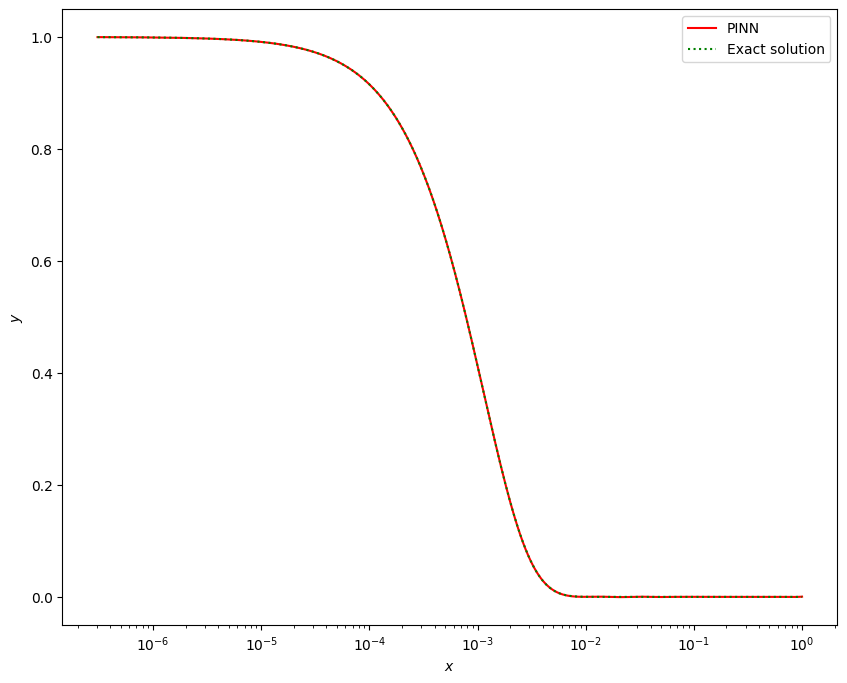

-----------------------------------------
Running for C = 1438.449888287663
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.714809 | ODE: 0.029278 | IC: 0.685531
Epoch 10000 | Best: 0.023677 | Total: 0.023668 | ODE: 0.022292 | IC: 0.001376
Epoch 20000 | Best: 0.001121 | Total: 0.001120 | ODE: 0.001119 | IC: 0.000001
Epoch 30000 | Best: 0.000087 | Total: 0.000092 | ODE: 0.000088 | IC: 0.000004
Epoch 40000 | Best: 0.000016 | Total: 0.000019 | ODE: 0.000016 | IC: 0.000003
Epoch 50000 | Best: 0.000008 | Total: 0.000008 | ODE: 0.000008 | IC: 0.000000
Epoch 60000 | Best: 0.000006 | Total: 0.000006 | ODE: 0.000006 | IC: 0.000000
Epoch 70000 | Best: 0.000004 | Total: 0.000004 | ODE: 0.000004 | IC: 0.000000
Epoch 80000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 90000 | Best: 0.000003 | Total: 0.000003 | ODE: 0.000003 | IC: 0.000000
Epoch 100000 | Best: 0.000002 | Total: 0.000003 | ODE: 0.000002 | IC: 0.000001
Epoch 110000 | Best: 0.0

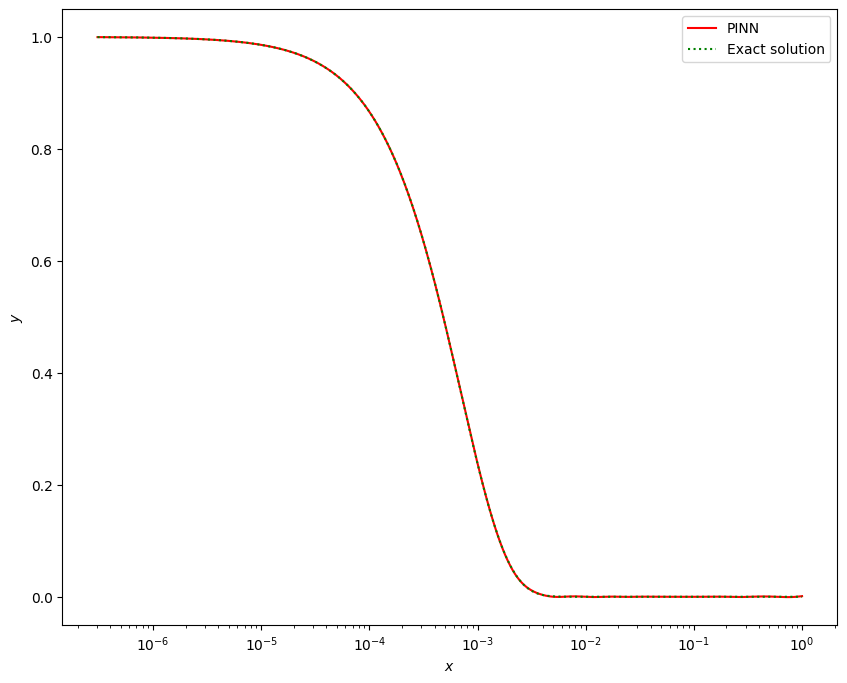

-----------------------------------------
Running for C = 2335.7214690901214
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 1.111111 | ODE: 0.002869 | IC: 1.108243
Epoch 10000 | Best: 0.110568 | Total: 0.110546 | ODE: 0.092140 | IC: 0.018406
Epoch 20000 | Best: 0.010523 | Total: 0.010520 | ODE: 0.010160 | IC: 0.000360
Epoch 30000 | Best: 0.001404 | Total: 0.001404 | ODE: 0.001394 | IC: 0.000010
Epoch 40000 | Best: 0.000207 | Total: 0.000209 | ODE: 0.000208 | IC: 0.000001
Epoch 50000 | Best: 0.000052 | Total: 0.000052 | ODE: 0.000052 | IC: 0.000000
Epoch 60000 | Best: 0.000023 | Total: 0.000023 | ODE: 0.000023 | IC: 0.000000
Epoch 70000 | Best: 0.000016 | Total: 0.000016 | ODE: 0.000016 | IC: 0.000000
Epoch 80000 | Best: 0.000012 | Total: 0.000012 | ODE: 0.000012 | IC: 0.000000
Epoch 90000 | Best: 0.000010 | Total: 0.000010 | ODE: 0.000010 | IC: 0.000000
Epoch 100000 | Best: 0.000008 | Total: 0.000008 | ODE: 0.000008 | IC: 0.000000
Epoch 110000 | Best: 0.

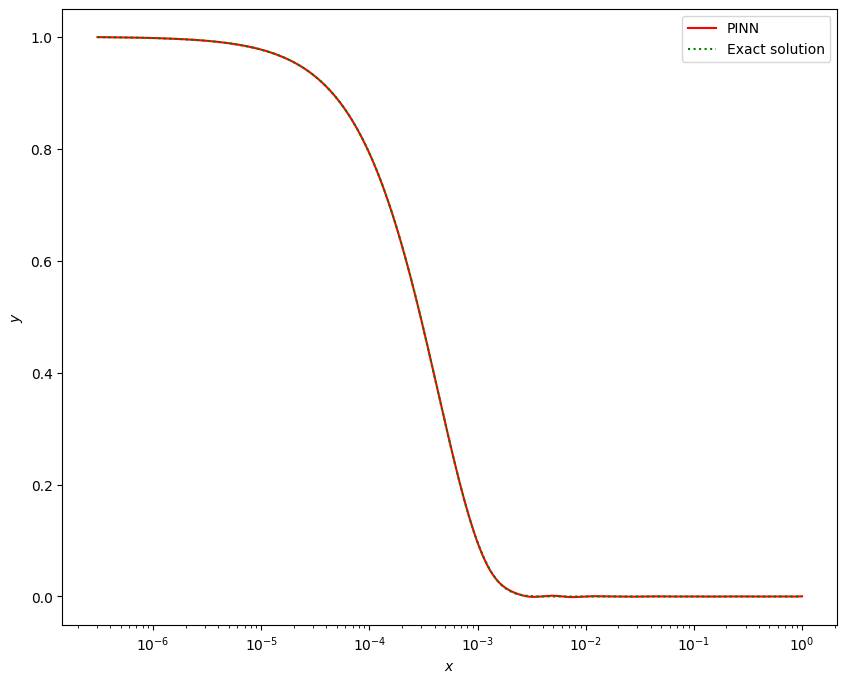

-----------------------------------------
Running for C = 3792.690190732246
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.911413 | ODE: 0.001913 | IC: 0.909499
Epoch 10000 | Best: 0.195840 | Total: 0.195825 | ODE: 0.149402 | IC: 0.046422
Epoch 20000 | Best: 0.054490 | Total: 0.054483 | ODE: 0.048570 | IC: 0.005913
Epoch 30000 | Best: 0.012545 | Total: 0.012553 | ODE: 0.012292 | IC: 0.000262
Epoch 40000 | Best: 0.003536 | Total: 0.003784 | ODE: 0.003332 | IC: 0.000452
Epoch 50000 | Best: 0.000689 | Total: 0.000689 | ODE: 0.000688 | IC: 0.000001
Epoch 60000 | Best: 0.000182 | Total: 0.000182 | ODE: 0.000182 | IC: 0.000000
Epoch 70000 | Best: 0.000078 | Total: 0.000077 | ODE: 0.000077 | IC: 0.000000
Epoch 80000 | Best: 0.000039 | Total: 0.000058 | ODE: 0.000040 | IC: 0.000018
Epoch 90000 | Best: 0.000023 | Total: 0.000284 | ODE: 0.000022 | IC: 0.000262
Epoch 100000 | Best: 0.000016 | Total: 0.000016 | ODE: 0.000016 | IC: 0.000001
Epoch 110000 | Best: 0.0

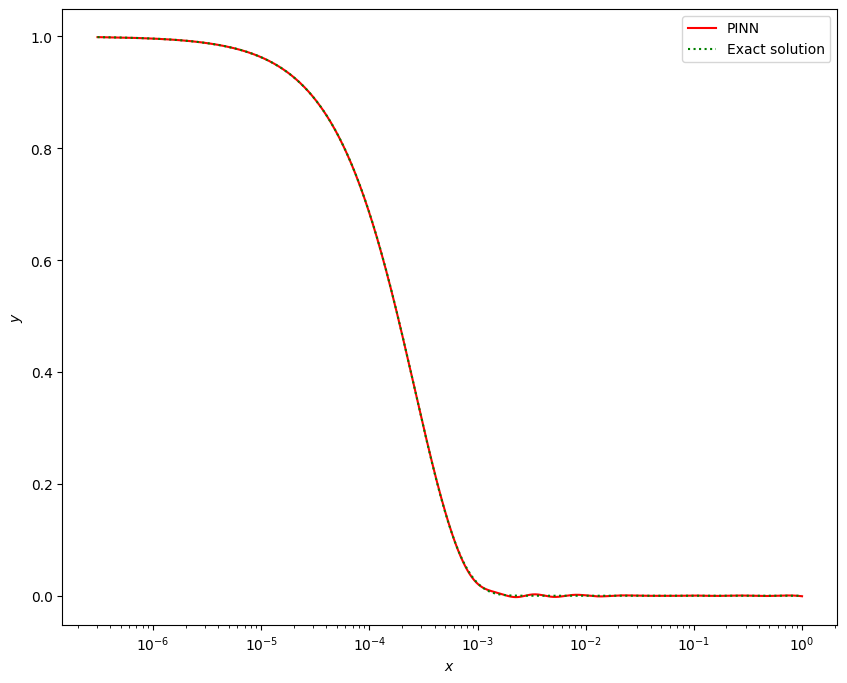

-----------------------------------------
Running for C = 6158.48211066026
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.942012 | ODE: 0.000778 | IC: 0.941233
Epoch 10000 | Best: 0.207122 | Total: 0.207334 | ODE: 0.148061 | IC: 0.059273
Epoch 20000 | Best: 0.062037 | Total: 0.062039 | ODE: 0.055904 | IC: 0.006135
Epoch 30000 | Best: 0.014534 | Total: 0.014532 | ODE: 0.013946 | IC: 0.000586
Epoch 40000 | Best: 0.003928 | Total: 0.003927 | ODE: 0.003879 | IC: 0.000049
Epoch 50000 | Best: 0.001154 | Total: 0.001154 | ODE: 0.001146 | IC: 0.000009
Epoch 60000 | Best: 0.000363 | Total: 0.000362 | ODE: 0.000360 | IC: 0.000002
Epoch 70000 | Best: 0.000126 | Total: 0.000126 | ODE: 0.000126 | IC: 0.000000
Epoch 80000 | Best: 0.000064 | Total: 0.000064 | ODE: 0.000064 | IC: 0.000000
Epoch 90000 | Best: 0.000042 | Total: 0.000207 | ODE: 0.000046 | IC: 0.000161
Epoch 100000 | Best: 0.000031 | Total: 0.000033 | ODE: 0.000031 | IC: 0.000002
Epoch 110000 | Best: 0.00

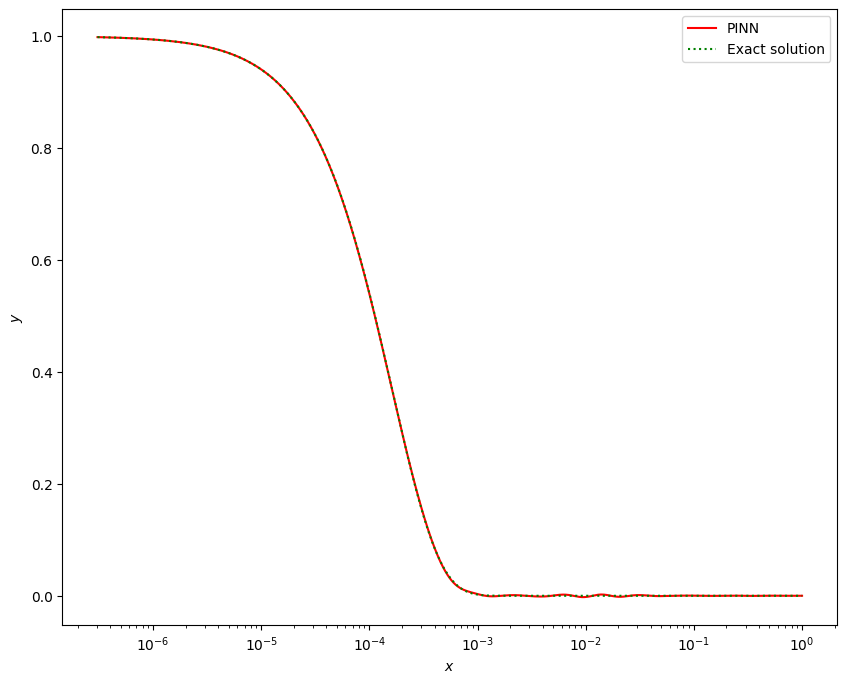

-----------------------------------------
Running for C = 10000.0
-----------------------------------------
Epoch   0 | Best: 10.000000 | Total: 0.870807 | ODE: 0.004436 | IC: 0.866371
Epoch 10000 | Best: 0.272963 | Total: 0.273062 | ODE: 0.186043 | IC: 0.087019
Epoch 20000 | Best: 0.181110 | Total: 0.181283 | ODE: 0.146304 | IC: 0.034979
Epoch 30000 | Best: 0.109698 | Total: 0.109692 | ODE: 0.092388 | IC: 0.017304
Epoch 40000 | Best: 0.059802 | Total: 0.059800 | ODE: 0.054078 | IC: 0.005722
Epoch 50000 | Best: 0.032881 | Total: 0.032889 | ODE: 0.031154 | IC: 0.001735
Epoch 60000 | Best: 0.016065 | Total: 0.016453 | ODE: 0.016415 | IC: 0.000038
Epoch 70000 | Best: 0.009179 | Total: 0.009999 | ODE: 0.008250 | IC: 0.001749
Epoch 80000 | Best: 0.004946 | Total: 0.004946 | ODE: 0.004872 | IC: 0.000074
Epoch 90000 | Best: 0.002549 | Total: 0.002549 | ODE: 0.002535 | IC: 0.000014
Epoch 100000 | Best: 0.001415 | Total: 0.001509 | ODE: 0.001460 | IC: 0.000050
Epoch 110000 | Best: 0.000684 | To

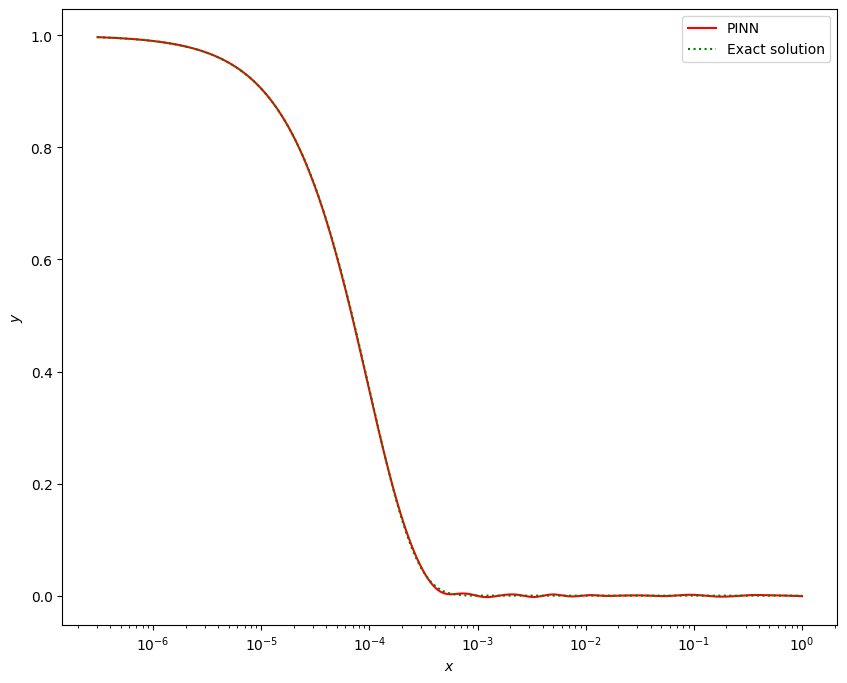

In [7]:
lst_eig_max = experiment(C_test, n_epochs)

## Maximum eigenvalues 

In [8]:
# Print list of maximum hessian eigenvalues
print("Eigenvalue list:")
print([round(x, 2) for x in lst_eig_max])

Eigenvalue list:
[3.73, 6.02, 5.03, 8.1, 8.17, 8.72, 14.17, 20.51, 15.71, 31.6, 34.42, 34.25, 29.79, 93.91, 56.58, 197.06, 262.37, 779.46, 15014.76, 1838.76]
